In [ ]:
from re import M
import numpy as np
import pymc as pm
import arviz as az
from scipy.stats import norm

# black scholes price
import numpy as np
import pymc as pm
import pytensor.tensor as pt
from scipy.stats import norm
import pytensor.tensor as pt

def normal_cdf(x):
    return 0.5 * pm.math.erfc(-x / pm.math.sqrt(2.0))

def black_scholes_price(S, K, T, r, sigma, option_type="call"):
    eps = 1e-12

    # Detect symbolic case
    symbolic = isinstance(S, pt.Variable) or isinstance(sigma, pt.Variable)

    if symbolic:
        T_safe = pm.math.maximum(T, eps)
        sigma_safe = pm.math.maximum(sigma, eps)

        d1 = (pm.math.log(S / K) + (r + 0.5 * sigma_safe**2) * T_safe) / (sigma_safe * pm.math.sqrt(T_safe))
        d2 = d1 - sigma_safe * pm.math.sqrt(T_safe)

        Nd1 = normal_cdf(d1)
        Nd2 = normal_cdf(d2)

        if option_type == "call":
            return S * Nd1 - K * pm.math.exp(-r * T_safe) * Nd2
        else:
            return K * pm.math.exp(-r * T_safe) * normal_cdf(-d2) - S * normal_cdf(-d1)


    else:
        # --- Numeric version for outside PyMC ---
        S = np.asarray(S, dtype=float)
        K = np.asarray(K, dtype=float)
        T = np.asarray(T, dtype=float)
        sigma = np.asarray(sigma, dtype=float)

        T_safe = np.clip(T, eps, None)
        sigma_safe = np.clip(sigma, eps, None)

        d1 = (np.log(S/K) + (r + 0.5*sigma_safe**2)*T_safe) / (sigma_safe*np.sqrt(T_safe))
        d2 = d1 - sigma_safe*np.sqrt(T_safe)

        if option_type == "call":
            price = S*norm.cdf(d1) - K*np.exp(-r*T_safe)*norm.cdf(d2)
        else:
            price = K*np.exp(-r*T_safe)*norm.cdf(-d2) - S*norm.cdf(-d1)

        # Use intrinsic value if maturity is effectively zero
        intrinsic = np.maximum(S-K, 0) if option_type=="call" else np.maximum(K-S, 0)
        price = np.where(T <= eps, intrinsic, price)

        return price


def model_1(observed_stock_prices, S0, K, T):
    # r_ti = log(s_ti / s_t(i-1)) ~ N((mu - 0.5 * sigma^2) * delta_t, sigma^2 * delta_t)
    # mu ~ N(0, delta_mu^2)
    # sigma ~ HalfNormal(delta_sigma)
    # p(theta1|Dt_stock) ∝ phi(mu|delta_mu^2).phi+(sigma|delta_sigma).L(Dt_stock|theta1)
    # No risk-free rate r in this model
    delta_t = 1 / 250
    log_return = np.diff(np.log(observed_stock_prices))
    #delta_t = 1 / 252  # Assuming equal time intervals
    with pm.Model() as model:
        mu = pm.Normal("mu", mu=0, sigma=2.0)
        sigma = pm.HalfNormal("sigma", sigma=2.0)
        #sigma = 1.0

        expected_mean = (mu - 0.5 * sigma**2) * delta_t
        pm.Normal("obs", mu=expected_mean, sigma=sigma * np.sqrt(delta_t), observed=log_return) # r_ti = log(s_ti / s_t(i-1)) ~ N((mu - 0.5 * sigma^2) * delta_t, sigma^2 * delta_t)
        trace = pm.sample(1000, tune=500, return_inferencedata=True, target_accept=0.95)

    summary = az.summary(trace, var_names=["mu", "sigma"])
    return trace, summary

def model_2(observed_stock_prices, call_prices, S0, K, toi):
    # theta2 = (mu, sigma, r, tol_sigma_call)
    # call_price_ti = call_black_scholes + epsilon_ti
    # epsilon_ti ~ N(0, tol_sigma_call^2)
    # toi = time to maturity at observation i
    # tol_sigma_call ~ HalfNormal(delta_call)
    # mu ~ N(0, delta_mu^2)
    # sigma ~ HalfNormal(delta_sigma)
    # r ~ N(0, delta_r^2)
    # p(theta2|Dt_option) ∝ phi(mu|delta_mu^2).phi+(sigma|delta_sigma).phi(r|delta_r^2).phi+(tol_sigma_call|delta_call).L(Dt_stock union Dt_call|theta2)

    delta_call = 1
    delta_mu = 2.0
    delta_sigma = 2.0
    delta_r = 1.0
    delta_t = 1 / 250

    # Compute stock log-returns,r in paper
    log_returns = np.diff(np.log(observed_stock_prices))
    S_t = observed_stock_prices[1:]

    with pm.Model() as model:
        # Priors from paper
        mu = pm.Normal("mu", mu=0, sigma=delta_mu)
        sigma = pm.HalfNormal("sigma", sigma=delta_sigma)
        r_param = pm.Normal("r", mu=0, sigma=delta_r)
        tol_sigma_call = pm.HalfNormal("tol_sigma_call", sigma=delta_call)


        expected_mean = (mu - 0.5 * sigma**2) * delta_t # likelihoods for r_t process
        pm.Normal("returns",
                  mu=expected_mean,
                  sigma=sigma * pm.math.sqrt(delta_t),
                  observed=log_returns)


        for i in range(len(toi)): # likelihood for call prices
            expected_call = black_scholes_price(S_t[i], K, toi[i],
                                                r_param, sigma, option_type="call")
            pm.Normal(f"call_obs_{i}",
                      mu=expected_call,
                      sigma=tol_sigma_call* pm.math.sqrt(toi[i]),
                      observed=call_prices[i]) # c_t = c_t_black_scholes + noise

        trace = pm.sample(1000, tune=500, return_inferencedata=True, target_accept=0.95)

    summary = az.summary(trace, var_names=["mu", "sigma", "r", "tol_sigma_call"])
    return trace, summary

def bs_price_symbolic(S, K, tau, r, sigma, option_type): # BS for model 3
    d1 = (pt.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * pt.sqrt(tau))
    d2 = d1 - sigma * pt.sqrt(tau)

    Nd1 = 0.5 * (1 + pm.math.erf(d1 / pt.sqrt(2)))
    Nd2 = 0.5 * (1 + pm.math.erf(d2 / pt.sqrt(2)))

    call = S * Nd1 - K * pt.exp(-r * tau) * Nd2
    put = call - S + K * pt.exp(-r * tau)

    return pt.switch(pt.eq(option_type, 1), call, put)

def model_3(observed_stock_prices, call_prices, put_prices, S0, K, toi,
            delta_t=1/250, draws=3000, tune=1500, target_accept=0.95, random_seed=42):

    # theta3 = (mu, sigma, r, tol_sigma_call, tol_sigma_put, rho)
    # r_ti = log(s_ti / s_t(i-1)) ~ N((mu - 0.5 * sigma^2)*delta_t, sigma^2*delta_t)
    # call_price_ti = C_BS + epsilon_tci
    # put_price_ti  = P_BS + epsilon_tpi
    # [epsilon_tci, epsilon_tpi]^T ~ N(0, Σ)
    # Σ = [[tol_sigma_call^2, rho*tol_sigma_call*tol_sigma_put],
    #      [rho*tol_sigma_call*tol_sigma_put, tol_sigma_put^2]]
    # mu ~ N(0, delta_mu^2)
    # sigma ~ HalfNormal(delta_sigma)
    # r ~ N(0, delta_r^2)
    # tol_sigma_call, tol_sigma_put ~ HalfNormal(delta_call, delta_put)
    # rho ~ Uniform(-1, 1)
    # p(theta3|Dt_stock∪Dt_call∪Dt_put) ∝ priors × likelihoods

    # Compute log returns for stock likelihood, r_ti
    log_returns = np.diff(np.log(observed_stock_prices))

    with pm.Model() as model:

        mu = pm.Normal("mu", mu=0, sigma=2.0)            # μ
        sigma = pm.HalfNormal("sigma", sigma=2.0)        # σ
        r = pm.Normal("r", mu=0, sigma=1.0)              # r

        chol, corr, sigmas = pm.LKJCholeskyCov(  # LKJ priors, from paper
            "chol_cov",
            n=2,
            eta=2.0,
            sd_dist=pm.HalfNormal.dist(1.0),
            compute_corr=True
        )

        sigma_c = pm.Deterministic("tol_sigma_call", sigmas[0])
        sigma_p = pm.Deterministic("tol_sigma_put", sigmas[1])
        rho = pm.Deterministic("rho", corr[0, 1])

        Sigma = pm.math.dot(chol, chol.T)    # Covariance Σ

        expected_mean = (mu - 0.5 * sigma**2) * delta_t
        pm.Normal("stock_returns",
                  mu=expected_mean,
                  sigma=sigma * np.sqrt(delta_t),
                  observed=log_returns)

        S_t = observed_stock_prices[1:]

        # Theoretical prices (vectorized BS)
        C_hat = bs_price_symbolic(S_t, K, toi, r, sigma, option_type=1)
        P_hat = bs_price_symbolic(S_t, K, toi, r, sigma, option_type=0)

        # Stack observed and mean vectors
        y_obs = pt.stack([call_prices, put_prices], axis=1)
        mu_vec = pt.stack([C_hat, P_hat], axis=1)

        # Scale Σ by tau_i: cov_i = tau_i * Σ   (paper Equation 10–11)
        toi_tensor = pt.as_tensor_variable(toi)
        covs = toi_tensor[:, None, None] * Sigma

        pm.MvNormal("options",
                    mu=mu_vec,
                    cov=covs,
                    observed=y_obs) # call and option price with covariance error

        trace = pm.sample(draws=draws, tune=tune, target_accept=target_accept, random_seed=random_seed)

    summary = az.summary(trace, var_names=["mu", "sigma", "r", "tol_sigma_call", "tol_sigma_put", "rho"])
    return trace, summary






def model_4_parity(observed_stock_prices, call_prices, put_prices, K, toi,
                   draws=1500, tune=1000, chains=2, random_seed=1):
    # theta4 = (mu, sigma, r, tol_sigma_call, tol_sigma_put)
    # r_ti = log(s_ti / s_t(i-1)) ~ N((mu - 0.5 * sigma^2) * delta_t, sigma^2 * delta_t)
    # C_ti = Ĉ_ti + ε_tci
    # ε_tci ~ N(0, τ_i * tol_sigma_call^2)
    # P_ti = C_ti - S_ti + K * exp(-r * τ_i) + ε_tpi
    # ε_tpi ~ N(0, τ_i * tol_sigma_put^2)
    # tol_sigma_call, tol_sigma_put ~ HalfNormal(delta_call, delta_put)
    # mu ~ N(0, delta_mu^2)
    # sigma ~ HalfNormal(delta_sigma)
    # r ~ N(0, delta_r^2)
    # p(theta4 | Dt_stock ∪ Dt_call ∪ Dt_put) ∝ phi(mu | delta_mu^2) phi+(sigma | delta_sigma) phi(r | delta_r^2) phi(r | delta_r^2) phi+(sigma_c | delta_c) phi+(sigma_p | delta_p) L(Dt_stock U Dt_call U Dt_put | theta4)
    delta_t = 1.0 / 250.0
    delta_mu = 2.0
    delta_sigma = 2.0
    delta_r = 1.0
    delta_call = 1.0
    delta_put = 1.0

    log_returns = np.diff(np.log(observed_stock_prices))  # log returns, r_t
    S_t = observed_stock_prices[1:]  # Current stock prices for options

    with pm.Model() as model:
        # Priors
        mu = pm.Normal("mu", 0, 10)
        sigma = pm.HalfNormal("sigma", 1)
        r = pm.Normal("r", 0, 1)
        tol_sigma_call = pm.HalfNormal("tol_sigma_call", 1)
        tol_sigma_put = pm.HalfNormal("tol_sigma_put", 1)

        expected_mean = (mu - 0.5 * sigma**2) * delta_t
        pm.Normal("stock_returns",
                 mu=expected_mean,
                 sigma=sigma * np.sqrt(delta_t),
                 observed=log_returns) # log returns, r_ti

        for i in range(len(call_prices)):
            C_hat = black_scholes_price(S_t[i], K, toi[i], r, sigma, "call")
            pm.Normal(f"call_{i}",
                     mu=C_hat,
                     sigma=np.sqrt(toi[i]) * tol_sigma_call,
                     observed=call_prices[i]) # call price with epsilon error

        for i in range(len(put_prices)):
            # P_ti = C_ti - S_ti + K*exp(-rτ_i) + ε_ti^p
            P_hat_parity = call_prices[i] - S_t[i] + K * pt.exp(-r * toi[i]) # put call parity eqn
            pm.Normal(f"put_{i}",
                     mu=P_hat_parity,
                     sigma=np.sqrt(toi[i]) * tol_sigma_put,
                     observed=put_prices[i])

        trace = pm.sample(draws=draws, tune=tune, chains=chains,
                         random_seed=random_seed, target_accept=0.95,
                         return_inferencedata=True)

    summary = az.summary(trace, var_names=["mu", "sigma", "r", "tol_sigma_call", "tol_sigma_put"])

    return trace, summary  # FIXED: Return trace and summary


🔹 Running calibration for window size 40...


Output()

✅ Completed window size 40 in 126.09566807746887 seconds


Output()

✅ Completed window size 40 in 6.710874319076538 seconds


Output()

✅ Completed window size 40 in 214.79944014549255 seconds


Output()

✅ Completed window size 40
✅ Completed window size 40 in 834.2542662620544 seconds


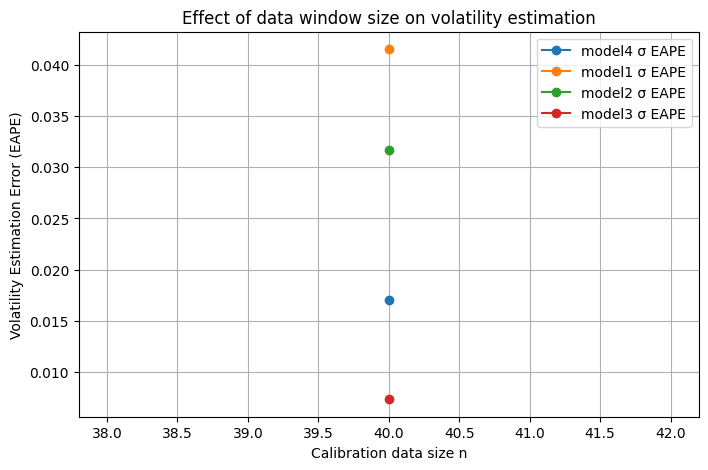

In [ ]:
# maximum a posteriori estimation and expected a posteriori estimation

from scipy.stats import gaussian_kde
import time

def compute_MAPE_EAPE(trace, params_names):
    """
    Compute MAPE and EAPE correctly:
    - EAPE = Expected A Posteriori = MEAN of posterior
    - MAPE = Maximum A Posteriori = MODE (maximum) of posterior
    """
    mape_dict = {}
    eape_dict = {}

    for name in params_names:
        samples = trace.posterior[name].values.flatten()

        # EAPE - Expected A Posteriori = MEAN
        eape_dict[name] = float(np.mean(samples))

        # MAPE - Maximum A Posteriori = MODE (maximum)
        # Use KDE to find the peak of the posterior
        kde = gaussian_kde(samples)
        x_range = np.linspace(np.min(samples), np.max(samples), 1000)
        densities = kde(x_range)
        mape_dict[name] = float(x_range[np.argmax(densities)])

    return mape_dict, eape_dict


# parameters for 4 models, used for MAPE, EAPE
params_1 = ["mu", "sigma"]
params_2 = ["mu", "sigma", "r", "tol_sigma_call"]
params_3 = ["mu", "sigma", "r", "tol_sigma_call", "tol_sigma_put", "rho"]
params_4 = ["mu", "sigma", "r", "tol_sigma_call", "tol_sigma_put"]

def simulate_data(N = 250, S0 = 10, T = 1.0, mu = 0.5, sigma = 1.0, sigma_c = 1.2, sigma_p = 1.0, r = 0.2, rho = -0.5, random_seed = 42, K = 10.0): # creating simulated data
  np.random.seed(random_seed)
  delta_t = T / N # time difference between 2 prices/events
  t_i = np.array([i * delta_t for i in range(1, N+1)])
  tau = T - t_i # time left for expiry

  dB = np.random.normal(0, np.sqrt(delta_t), size=N) # change due to brownian motion, deltaB
  B = np.cumsum(dB) # cumulative, summing changes till that time point

  S = S0 * np.exp((mu - 0.5 * sigma**2) * t_i + sigma * B) # standard gbm eqn for stock price

  c_hat = []
  p_hat = []
  for i in range(N):
    c_hat.append(black_scholes_price(S[i], K, tau[i], r, sigma, "call")) # standard black scholes prices of options
    p_hat.append(black_scholes_price(S[i], K, tau[i], r, sigma, "put"))

  c_hat = np.array(c_hat)
  p_hat = np.array(p_hat)

  eps_c = np.zeros(N) # epsilon, moise for option prices
  eps_p = np.zeros(N)
  Sigma = np.array([ # correlation
        [sigma_c**2, rho * sigma_c * sigma_p],
        [rho * sigma_c * sigma_p, sigma_p**2]
  ])

  for i in range(N):
    cov_i = tau[i] * Sigma
    eps_i = np.random.multivariate_normal(np.zeros(2), cov_i)
    eps_c[i] = eps_i[0]
    eps_p[i] = eps_i[1]

  C_obs = c_hat + eps_c
  P_obs = p_hat + eps_p

  return t_i, tau, S, C_obs, P_obs, c_hat, p_hat


def posterior_std(trace, names):
    out = {}
    for name in names:
        if name in trace.posterior.data_vars:
            vals = trace.posterior[name].values.flatten()
            out[name] = float(np.std(vals))
        else:
            out[name] = np.nan
    return out

t_i, tau, S, C_obs, P_obs, C_hat, P_hat = simulate_data()
# --------------------------
# Dynamic calibration test
# --------------------------

i = 100  # fixed point (used in paper)
window_lengths = [40]
true_params = {"mu": 0.5, "sigma": 1.0, "r": 0.2}
S0 = 10
K = 10
# Initialize results dictionary
results = {
    "model1": {"n": [], "EAPE_sigma": [], "MAPE_sigma": [], "PSTD_sigma": []},
    "model2": {"n": [], "EAPE_sigma": [], "MAPE_sigma": [], "PSTD_sigma": [],
               "EAPE_r": [], "MAPE_r": [], "PSTD_r": []},
    "model3": {"n": [], "EAPE_sigma": [], "MAPE_sigma": [], "PSTD_sigma": [],
               "EAPE_r": [], "MAPE_r": [], "PSTD_r": []},
    "model4": {"n": [], "EAPE_sigma": [], "MAPE_sigma": [], "PSTD_sigma": [],
               "EAPE_r": [], "MAPE_r": [], "PSTD_r": []}
}

# Run calibration for each data window size
# Run calibration for each data window size
for window_size in window_lengths:
    start = i - window_size
    end = i
    stock_prices = S[start:end+1]
    call_prices = C_obs[start:end]
    put_prices = P_obs[start:end]
    toi = tau[start:end]

    print(f"\n🔹 Running calibration for window size {window_size}...")

    # ---------------------- MODEL 4 ----------------------
    time_start = time.time()
    trace, summary = model_4_parity(stock_prices, call_prices, put_prices, K, toi)
    mape_dict, eape_dict = compute_MAPE_EAPE(trace, ["mu", "sigma", "r", "tol_sigma_call", "tol_sigma_put"])
    pstd_dict = posterior_std(trace, ["mu", "sigma", "r", "tol_sigma_call", "tol_sigma_put"])

    # Compute relative errors (MAPE & EAPE)

    eape_sigma_err = abs(eape_dict["sigma"] - true_params["sigma"])
    mape_sigma_err = abs(mape_dict["sigma"] - true_params["sigma"])
    eape_r_err     = abs(eape_dict["r"] - true_params["r"])
    mape_r_err     = abs(mape_dict["r"] - true_params["r"])

    results["model4"]["n"].append(window_size)
    results["model4"]["EAPE_sigma"].append(eape_sigma_err)
    results["model4"]["MAPE_sigma"].append(mape_sigma_err)
    results["model4"]["PSTD_sigma"].append(pstd_dict["sigma"])
    results["model4"]["EAPE_r"].append(eape_r_err)
    results["model4"]["MAPE_r"].append(mape_r_err)
    results["model4"]["PSTD_r"].append(pstd_dict["r"])
    time_end = time.time()
    print(f"✅ Completed window size {window_size} in {time_end - time_start} seconds")



    # ---------------------- MODEL 1 ----------------------
    time_start = time.time()
    trace, summary = model_1(stock_prices, S0, K, toi)
    mape_dict, eape_dict = compute_MAPE_EAPE(trace, ["mu", "sigma"])
    pstd_dict = posterior_std(trace, ["mu", "sigma"])

    eape_sigma_err = abs(eape_dict["sigma"] - true_params["sigma"])
    mape_sigma_err = abs(mape_dict["sigma"] - true_params["sigma"])

    results["model1"]["n"].append(window_size)
    results["model1"]["EAPE_sigma"].append(eape_sigma_err)
    results["model1"]["MAPE_sigma"].append(mape_sigma_err)
    results["model1"]["PSTD_sigma"].append(pstd_dict["sigma"])
    time_end = time.time()
    print(f"✅ Completed window size {window_size} in {time_end - time_start} seconds")


    # ---------------------- MODEL 2 ----------------------
    time_start = time.time()
    trace, summary = model_2(stock_prices, call_prices, S0, K, toi)
    mape_dict, eape_dict = compute_MAPE_EAPE(trace, ["mu", "sigma", "r", "tol_sigma_call"])
    pstd_dict = posterior_std(trace, ["mu", "sigma", "r", "tol_sigma_call"])

    eape_sigma_err = abs(eape_dict["sigma"] - true_params["sigma"])
    mape_sigma_err = abs(mape_dict["sigma"] - true_params["sigma"])
    eape_r_err     = abs(eape_dict["r"] - true_params["r"])
    mape_r_err     = abs(mape_dict["r"] - true_params["r"])

    results["model2"]["n"].append(window_size)
    results["model2"]["EAPE_sigma"].append(eape_sigma_err)
    results["model2"]["MAPE_sigma"].append(mape_sigma_err)
    results["model2"]["PSTD_sigma"].append(pstd_dict["sigma"])
    results["model2"]["EAPE_r"].append(eape_r_err)
    results["model2"]["MAPE_r"].append(mape_r_err)
    results["model2"]["PSTD_r"].append(pstd_dict["r"])
    time_end = time.time()
    print(f"✅ Completed window size {window_size} in {time_end - time_start} seconds")


    # ---------------------- MODEL 3 ----------------------
    time_start = time.time()
    trace, summary = model_3(stock_prices, call_prices, put_prices, S0, K, toi)
    mape_dict, eape_dict = compute_MAPE_EAPE(trace, ["mu", "sigma", "r", "tol_sigma_call", "tol_sigma_put", "rho"])
    pstd_dict = posterior_std(trace, ["mu", "sigma", "r", "tol_sigma_call", "tol_sigma_put", "rho"])

    eape_sigma_err = abs(eape_dict["sigma"] - true_params["sigma"])
    mape_sigma_err = abs(mape_dict["sigma"] - true_params["sigma"])
    eape_r_err     = abs(eape_dict["r"] - true_params["r"])
    mape_r_err     = abs(mape_dict["r"] - true_params["r"])

    results["model3"]["n"].append(window_size)
    results["model3"]["EAPE_sigma"].append(eape_sigma_err)
    results["model3"]["MAPE_sigma"].append(mape_sigma_err)
    results["model3"]["PSTD_sigma"].append(pstd_dict["sigma"])
    results["model3"]["EAPE_r"].append(eape_r_err)
    results["model3"]["MAPE_r"].append(mape_r_err)
    results["model3"]["PSTD_r"].append(pstd_dict["r"])

    print(f"✅ Completed window size {window_size}")
    time_end = time.time()
    print(f"✅ Completed window size {window_size} in {time_end - time_start} seconds")



# -----------------------------
# Plot σ (volatility) estimation
# -----------------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
for model in ["model4", "model1", "model2", "model3"]:
    plt.plot(results[model]["n"], results[model]["EAPE_sigma"], marker='o', label=f"{model} σ EAPE")
plt.xlabel("Calibration data size n")
plt.ylabel("Volatility Estimation Error (EAPE)")
plt.title("Effect of data window size on volatility estimation")
plt.legend()
plt.grid(True)
plt.show()







In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Effect of Calibration Data Size (n) on Parameter Estimation", fontsize=14)

# --- Define metrics to loop over ---
metrics_sigma = ["MAPE_sigma", "EAPE_sigma", "PSTD_sigma"]
metrics_r = ["MAPE_r", "EAPE_r", "PSTD_r"]
titles_sigma = ["Errors of MAPE for σ", "Errors of EAPE for σ", "PSTD of σ"]
titles_r = ["Errors of MAPE for r", "Errors of EAPE for r", "PSTD of r"]

# --- Colors & styles for each model ---
model_styles = {
    "model1": {"color": "blue", "marker": "*", "linestyle": "-"},
    "model2": {"color": "green", "marker": "v", "linestyle": "-"},
    "model3": {"color": "red", "marker": "o", "linestyle": "--"},
    "model4": {"color": "black", "marker": "+", "linestyle": "-"}
}

# --- Plot σ metrics ---
for j, metric in enumerate(metrics_sigma):
    ax = axes[0, j]
    for model, style in model_styles.items():
        if metric in results[model]:
            ax.plot(results[model]["n"], results[model][metric],
                    label=f"{model.replace('model', 'Model ')}",
                    color=style["color"], marker=style["marker"], linestyle=style["linestyle"])
    ax.set_title(titles_sigma[j])
    ax.set_xlabel("n")
    ax.set_ylabel("Error")
    ax.grid(True)
    if j == 1:
        ax.legend()

# --- Plot r metrics ---
for j, metric in enumerate(metrics_r):
    ax = axes[1, j]
    for model, style in model_styles.items():
        if metric in results[model]:
            ax.plot(results[model]["n"], results[model][metric],
                    label=f"{model.replace('model', 'Model ')}",
                    color=style["color"], marker=style["marker"], linestyle=style["linestyle"])
    ax.set_title(titles_r[j])
    ax.set_xlabel("n")
    ax.set_ylabel("Error")
    ax.grid(True)
    if j == 1:
        ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
eape_dict["sigma"]

In [ ]:
results["model3"]

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
for model in ["model4", "model1", "model2", "model3"]:
    plt.plot(results[model]["n"], results[model]["EAPE_sigma"], marker='o', label=f"{model} σ EAPE")
plt.xlabel("Calibration data size n")
plt.ylabel("Volatility Estimation Error (EAPE)")
plt.title("Effect of data window size on volatility estimation")
plt.legend()
plt.grid(True)
plt.show()